# KNN 분류 복습 실습 문제지
### K-최근접 이웃 · 학습/테스트 분리 · 스케일링

> **목적**: KNN 함수 암기가 아니라, "왜 이 모델이 이 자리에서 이렇게 동작하는가"를 판단하는 훈련.
> **데이터**: 생선(도미/빙어, 다중 생선), 붓꽃(iris)
> **구성**: 3개 레벨 × 3문제 = 총 9문제
> **푸는 법**: 코드를 직접 쳐서 출력을 확인하고, 각 문제의 **사고 과제**에 한 줄로 답한다.

In [20]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

# 도미/빙어 데이터
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

fish_length = bream_length + smelt_length
fish_weight = bream_weight + smelt_weight
fish_data = np.column_stack((fish_length, fish_weight))
fish_target = np.array([1] * 35 + [0] * 14)   # 1=도미, 0=빙어

# LEVEL 1 — 도구 장악
> KNN의 각 메서드가 실제로 무슨 일을 하는지 손으로 확인한다. 출력 모양을 반드시 눈으로 본다.

---

### 문제 1-1. fit / predict / score가 각각 하는 일

도미/빙어 데이터로 KNN 모델(`n_neighbors=5`)을 만들고:
1. `fit`으로 학습시켜라
2. `score`로 학습 데이터 자체의 정확도를 구해라
3. 새 데이터 `[[30, 600], [12, 12]]`를 `predict`해라 (각각 도미/빙어 예상)

**사고 과제**: 2번에서 학습에 쓴 데이터를 그대로 평가하면 점수가 1.0(100%)이 나온다. 이 점수를 "이 모델 성능 좋다"는 근거로 쓰면 안 되는 이유는?

In [4]:
kn_clf = KNeighborsClassifier()
kn_clf.fit(fish_data, fish_target)
kn_clf.score(fish_data, fish_target)
kn_clf.predict([[30,600],[12,12]])

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

### 문제 1-2. KNN은 "학습"할 때 무슨 일을 하나

`fit`을 호출한 뒤 `kn_clf._fit_X`와 `kn_clf._y`를 출력해보라. 그리고 학습 전후로 모델이 뭘 "기억"하고 있는지 확인하라.

**사고 과제**: 선형회귀 같은 모델은 학습하면서 "수식의 계수"를 계산한다. 그런데 KNN의 `fit`은 사실상 데이터를 **저장만** 한다. KNN이 "게으른 학습기(lazy learner)"라고 불리는 이유를 이 관찰과 연결해 설명하라.

In [7]:
kn_clf._fit_X
# kn_clf._y

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


### 문제 1-3. 예측의 근거 — kneighbors로 이웃 들여다보기

새 데이터 `[[40, 160]]`에 대해 `kneighbors`로 가장 가까운 이웃 5개의 **거리(distances)**와 **인덱스(indices)**를 구하라. 그리고 그 이웃들의 정답(`fish_target[indices]`)을 확인하라.

**사고 과제**: KNN의 예측 결과는 결국 이 이웃들의 다수결이다. 그렇다면 `n_neighbors`를 5에서 1로 바꾸면 예측이 어떻게 민감해지고, 49로 바꾸면(전체 개수) 무슨 일이 벌어지는가?

<Axes: >

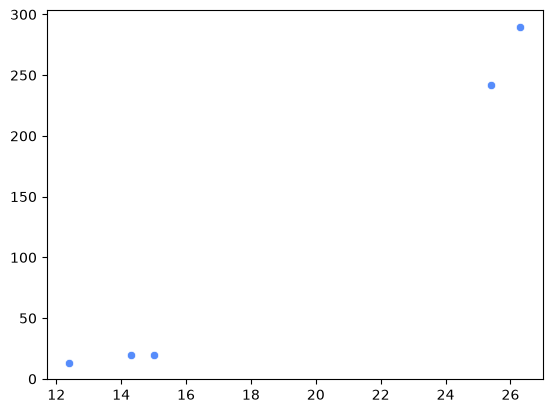

In [51]:
distances, indices = kn_clf.kneighbors([[40,160]], n_neighbors=5)

fish_target[indices]

neighbor_indices = indices.squeeze()

sns.scatterplot(
    x= fish_data[neighbor_indices, 0], y = fish_data[neighbor_indices, 1],
)

# LEVEL 2 — 진단 사고
> 모델이 "왜 틀리는가"를 진단한다. 오늘 수업의 핵심 사건인 "수상한 도미"가 여기 있다.

### 문제 2-1. train_test_split — 왜 나누나

전체 데이터를 학습용 80%, 테스트용 20%로 나눠라. `stratify=fish_target`를 넣은 경우와 뺀 경우의 차이를 확인하라. (특히 빙어가 14개뿐이라는 점에 주목)

**사고 과제**: `stratify`를 빼면 운 나쁘게 테스트셋에 빙어가 0마리 들어갈 수도 있다. 데이터가 적고 한쪽 클래스가 소수일 때 `stratify`가 왜 중요한지 설명하라.

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    fish_data,
    fish_target,
    test_size=0.2,
    stratify=fish_target,
    random_state=42,
)

print(y_test)

[1 0 1 1 0 1 1 1 0 1]


### 문제 2-2. 수상한 도미 사건

스케일링 **없이** train/test로 학습한 KNN에 도미 데이터 `[[25, 150]]`를 예측시켜라. 빙어(0)로 잘못 나올 것이다. `kneighbors`로 이웃을 찾고, 산점도에 **x축 범위를 `(0, 1000)`으로 강제 설정**해서 그려보라.

**사고 과제**: x축을 y축과 비슷한 큰 범위로 늘리면 점들이 한쪽으로 뭉쳐 보인다. 이 그림이 "왜 KNN이 도미를 빙어로 착각했는가"를 어떻게 설명하는가? (힌트: 길이 0~40 vs 무게 0~1000, 거리 계산에서 누가 이기나)

예측값: [0]


(0.0, 1000.0)

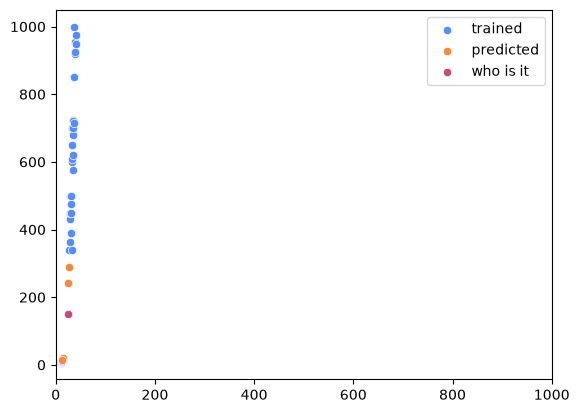

In [66]:
kn_clf.fit(X_train, y_train)
kn_clf.score(X_train, y_train)
print("예측값:", kn_clf.predict([[25,150]]))

distances, indices = kn_clf.kneighbors([[25,150]], n_neighbors=5)

sns.scatterplot(
    x = fish_data[:, 0],    # 물고기 길이
    y = fish_data[:, 1],    # 물고기 무게
    label = 'trained'
)

sns.scatterplot(
    x= fish_data[neighbor_indices, 0], y = fish_data[neighbor_indices, 1],
    label="predicted"
)

sns.scatterplot(
    x= [25], y = [150],
    label="who is it"
)
plt.xlim(0,1000)

### 문제 2-3. 거리 계산 직접 해보기

도미 `[25, 150]`과 임의의 빙어 한 마리, 임의의 도미 한 마리 사이의 **유클리드 거리**를 손으로(NumPy로) 계산하라. 무게 차이와 길이 차이가 각각 거리에 얼마나 기여하는지 숫자로 확인하라.

```python
# 유클리드 거리 = sqrt((x1-x2)^2 + (y1-y2)^2)
```

**사고 과제**: 길이 차이 5와 무게 차이 5는 같은 "5"지만, 거리 계산에서 똑같이 취급된다. 이게 왜 문제이고, 스케일링이 이걸 어떻게 해결하는지 한 줄로 답하라.

In [71]:
suspect = np.array([25,150])
a_bream = np.array([30, 600]) # 도미
a_smelt = np.array([12,10])   # 빙어

d_bream = np.sqrt(((suspect-a_bream)**2).sum())
d_smelt = np.sqrt(((suspect-a_smelt)**2).sum())

print("도미까지 거리:", d_bream)
print("빙어까지 거리:", d_smelt)

도미까지 거리: 450.0277769204919
빙어까지 거리: 140.60227594174995


# LEVEL 3 — 적용/판단 사고
> "이 모델을 제대로 쓰려면 무슨 판단을 해야 하나." 스케일링의 올바른 적용이 핵심이다.

### 문제 3-1. 스케일링 올바르게 적용하기

`StandardScaler`로 학습 데이터를 스케일링하고, KNN을 재학습시켜 "수상한 도미"가 이제 도미(1)로 제대로 분류되는지 확인하라. 단, 새 데이터 `[25, 150]`도 **반드시 같은 scaler로 변환**해서 예측에 넣어라.

**사고 과제**: 새 데이터를 스케일링하지 않고 원본 그대로 `predict`에 넣으면 어떤 일이 벌어지는가? 모델은 에러를 안 낼 수도 있는데, 그게 더 위험한 이유는?

In [73]:
scaler = StandardScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
WHOISIT = scaler.transform([[25, 150]])

kn_clf = KNeighborsClassifier()
kn_clf.fit(X_train_scaled, y_train)
kn_clf.score(X_train_scaled, y_train)
kn_clf.predict(WHOISIT)

array([1])

### 문제 3-2. fit_transform vs transform — 결정적 함정

학습 데이터엔 `scaler.fit_transform(X_train)`을, 테스트 데이터엔 `scaler.transform(X_test)`를 써야 한다. 만약 테스트 데이터에도 `fit_transform`을 쓰면 무엇이 잘못되는지, 두 경우의 평균/표준편차가 어디서 오는지 출력해서 비교하라.

**사고 과제**: 테스트 데이터로 scaler를 다시 `fit`하면, 테스트셋의 평균/표준편차 정보가 모델 파이프라인에 새어든다. 이것이 왜 "데이터 누수(data leakage)"이고, 실전 배포 시 왜 재앙이 되는지 설명하라. (힌트: 실전에서 새 데이터가 1개씩 들어올 때 그 1개로 평균을 낼 수 있나?)

### 문제 3-3. 붓꽃으로 전체 파이프라인 완성

`load_iris()`로 붓꽃 데이터를 불러와, 오늘 배운 전체 흐름을 처음부터 끝까지 한 번에 수행하라.
1. train/test split (stratify 적용)
2. StandardScaler로 스케일링 (fit_transform / transform 구분)
3. KNN(`n_neighbors=3`) 학습
4. 학습 점수와 테스트 점수를 각각 출력
5. `predict_proba`로 예측 확률도 확인

**사고 과제**: 학습 점수는 높은데 테스트 점수가 눈에 띄게 낮다면 무엇을 의심해야 하나? 반대로 둘 다 너무 완벽하게 1.0이면 뭘 점검해야 하나?

In [86]:
iris_df = load_iris()

print(iris_df.data)
print(iris_df.target)

X_train, X_test, y_train, y_test = train_test_split(
    iris_df.data,
    iris_df.target,
    test_size=0.2,
    stratify=iris_df.target,
    random_state=42,
)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

kn_clf = KNeighborsClassifier(n_neighbors=3)
kn_clf.fit(X_train_scaled, y_train)
print("학습 점수:", kn_clf.score(X_train_scaled, y_train))
print("테스트 점수:", kn_clf.score(X_test_scaled, y_test))
print("예측 확률:",kn_clf.predict_proba(X_test_scaled))



[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

## 최종 사고 과제 — 모범 답안 예시

> **가장 치명적인 약점: 스케일 민감성.**
> KNN은 거리로 모든 걸 판단하므로, 변수 스케일이 다르면 큰 범위 변수가 거리를 독점한다. 드론 텔레메트리는 이 문제가 극단적이다 — 고도(수백 m), 각속도(수 rad/s), 배터리 전압(수십 V), GPS 좌표(수만 단위)가 한 데이터에 섞여 있다. 스케일링 없이 KNN을 돌리면 GPS 좌표 하나가 모든 거리 계산을 지배해 다른 센서가 무시된다. 따라서 반드시 (1) 각 센서 채널을 표준화(StandardScaler)하고, (2) 시계열이므로 시간 누수를 막기 위해 과거 데이터로만 scaler를 fit해야 한다. 시간 순서를 무시하고 전체로 fit하면 미래 정보가 새어드는 누수가 발생한다.

---

## 마지막 한 마디

오늘 "수상한 도미" 한 사건이 KNN의 본질을 다 담고 있다. 모델은 멍청하지 않았다. 시킨 대로 거리를 쟀을 뿐이고, 문제는 **데이터를 어떤 상태로 줬는가**였다. 모델을 탓하기 전에 데이터 상태를 의심하는 것 — 그게 ML을 "돌리는 사람"과 "판단하는 사람"의 차이다.